In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import tifffile
import numpy as np

In [2]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Load CSV
data_csv = "/mnt/d/lding/CLS/mousumiLiuDinner/selected_for_annotation_mt_strcture_20250310_MA.csv"
image_dir = "/mnt/d/lding/CLS/mousumiLiuDinner/set1to5_processed_results/Microtubule_GUV-Liu-20250106T211105Z-001/processed_GUV_MT/from_annotation_to_circle_square_edge/MT_circle_crop_tiff"

df = pd.read_csv(data_csv)

for index, row in df.iterrows():
    index_select = int(row['filename'][-8:-4])
    
    if index_select in [18,21,328,480,356,543,669,78,242,726,762,771,812,977,983]:
        df.iloc[index]['label'] = 'poor'

df = df[df['label'] != 'poor']

# df = df[df['filename'] != '3_10 Tau_Tubulin-Date 4-3 Um TAU PLUS MT ENCAP GUV9_w2561.TIF_cell16_cellindex1030.png']


/tmp/ipykernel_456896/1156907384.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.iloc[index]['label'] = 'poor'


In [4]:
df = df.dropna(subset=["filename", "label"])
df["label"] = df["label"].astype(str)

# Split into Train (80%) & Validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# Define Transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.data = dataframe.copy()
        self.root_dir = root_dir
        self.transform = transform
        self.label_to_index = {label: idx for idx, label in enumerate(sorted(self.data["label"].unique()))}
        self.data["label"] = self.data["label"].map(self.label_to_index)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data.iloc[idx, 0]).replace('png','tif')
        np_image = tifffile.imread(img_name)
        
        # Normalize or ensure correct dtype (uint8)
        if np_image.dtype != 'uint8':
            np_image = (255 * (np_image / np_image.max())).astype('uint8')
        
        # Convert grayscale/single channel to RGB if needed
        if np_image.ndim == 2:  # grayscale
            np_image = np.stack([np_image]*3, axis=-1)  # H x W x 3

        image = Image.fromarray(np_image) 
        
        label = int(self.data.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# Create Datasets & DataLoaders
train_dataset = CustomDataset(train_df, image_dir, transform=train_transform)
val_dataset = CustomDataset(val_df, image_dir, transform=val_transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load EfficientNet-B0 Model & Modify for Classification
from torchvision.models import efficientnet_b0

model = efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),  # Add dropout to reduce overfitting
    nn.Linear(num_ftrs, len(train_dataset.label_to_index))
)
model = model.to(device)

# Define Focal Loss for better handling of class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)  # Probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=1, gamma=2)

# Use AdamW optimizer with weight decay for better generalization
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

# Learning rate scheduler to adjust learning rate dynamically
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# Training Loop with Early Stopping
num_epochs = 100
best_val_acc = 0
patience = 20
patience_counter = 0
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
    print(correct_train)
    print(total_train)
    train_loss = running_loss / len(train_dataloader)
    train_acc = correct_train / total_train
    
    # Validation Step
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
    
    val_loss = running_val_loss / len(val_dataloader)
    val_acc = correct_val / total_val
    print(correct_val)
    print(total_val)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")
    
    scheduler.step()  # Adjust learning rate
    
    # Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered. Best Validation Accuracy:", best_val_acc)
            break
    # Save the fine-tuned model

torch.save(model.state_dict(), '5classes_finetuned_model_orig_circle.pth')
print("Model saved successfully!")


/home/ldin/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


104
270
16
68
Epoch 1: Train Loss = 0.8203, Train Acc = 0.3852, Val Loss = 0.9934, Val Acc = 0.2353
155
270
23
68
Epoch 2: Train Loss = 0.4851, Train Acc = 0.5741, Val Loss = 0.7953, Val Acc = 0.3382
188
270
27
68
Epoch 3: Train Loss = 0.3126, Train Acc = 0.6963, Val Loss = 0.6082, Val Acc = 0.3971
197
270
35
68
Epoch 4: Train Loss = 0.2170, Train Acc = 0.7296, Val Loss = 0.4912, Val Acc = 0.5147
224
270
40
68
Epoch 5: Train Loss = 0.0987, Train Acc = 0.8296, Val Loss = 0.3983, Val Acc = 0.5882
230
270
43
68
Epoch 6: Train Loss = 0.0678, Train Acc = 0.8519, Val Loss = 0.4663, Val Acc = 0.6324
249
270
39
68
Epoch 7: Train Loss = 0.0477, Train Acc = 0.9222, Val Loss = 0.6044, Val Acc = 0.5735
244
270
42
68
Epoch 8: Train Loss = 0.0408, Train Acc = 0.9037, Val Loss = 0.6149, Val Acc = 0.6176
253
270
46
68
Epoch 9: Train Loss = 0.0225, Train Acc = 0.9370, Val Loss = 0.4858, Val Acc = 0.6765
247
270
43
68
Epoch 10: Train Loss = 0.0168, Train Acc = 0.9148, Val Loss = 0.4818, Val Acc = 0.6324

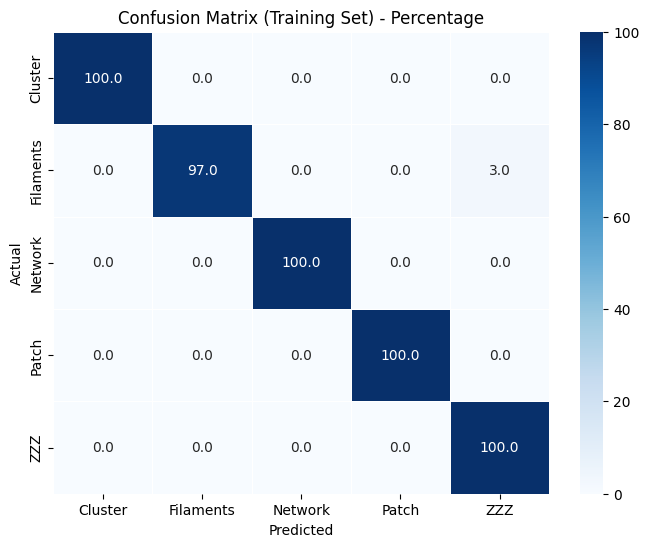

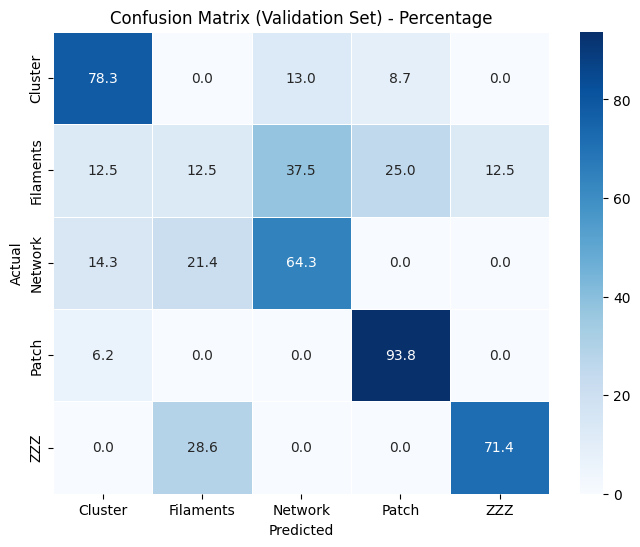

In [6]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

import numpy as np
# Function to evaluate model and plot confusion matrix with percentages
def evaluate_model(dataloader, dataset_name):
    true_labels, pred_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(true_labels, pred_labels)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentages
    labels = list(train_dataset.label_to_index.keys())
    cm_df = pd.DataFrame(cm_percentage, index=labels, columns=labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({dataset_name}) - Percentage")
    plt.show()

evaluate_model(train_dataloader, "Training Set")
evaluate_model(val_dataloader, "Validation Set")

In [ ]:
import numpy as np
# Function to evaluate model and plot confusion matrix with percentages
def evaluate_model(dataloader, dataset_name):
    true_labels, pred_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(true_labels, pred_labels)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentages
    labels = list(train_dataset.label_to_index.keys())
    cm_df = pd.DataFrame(cm_percentage, index=labels, columns=labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({dataset_name}) - Percentage")
    plt.show()

evaluate_model(train_dataloader, "Training Set")
evaluate_model(val_dataloader, "Validation Set")